In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("11_Baseketball_Team_Performance_Analysis.csv")
df.head()

,id,year,rank,school,games,wins,losses,win_percentage,conference_wins,conference_losses,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
0,1,2021,1,Villanova,38,30,8,0.789,16,4,...,10.3,34.8,11.9,6.0,2.2,9.9,14.9,71.7,62.7,19.31
1,2,2021,2,Providence,33,27,6,0.818,14,3,...,10.5,37.6,13.2,5.0,3.7,11.4,16.0,71.5,66.2,13.08
2,3,2021,3,UConn,33,23,10,0.697,13,6,...,13.8,40.4,14.0,5.9,6.4,11.8,16.8,74.8,65.3,16.40
3,4,2021,4,Creighton,35,23,12,0.657,12,7,...,9.6,38.1,13.3,5.5,4.3,14.1,13.6,69.2,66.4,11.34
4,5,2021,5,Marquette,32,19,13,0.594,11,8,...,7.8,34.8,16.0,7.8,5.2,12.4,17.4,74.0,71.6,11.36


In [17]:
df.shape

(10000, 37)

In [18]:
# checking null values
df.isnull().sum()

id                                   0
year                                 0
rank                                 0
school                               0
games                                0
wins                                 0
losses                               0
win_percentage                       0
conference_wins                      0
conference_losses                    0
home_wins                          208
home_losses                        208
away_wins                          208
away_losses                        208
offensive_rating                   278
defensive_rating                   278
net_rating                         278
field_goals                          0
field_goal_attempts                  0
field_goal_percentage                0
3_pointers                          58
3_pointer_attempts                  58
3_pointer_percentage                58
effective_field_goal_percentage     58
free_throws                          0
free_throw_attempts      

In [19]:
# filling null values with median
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# checking if nulls are gone
print("Nulls remaining:", df.isnull().sum().sum())

Nulls remaining: 2138


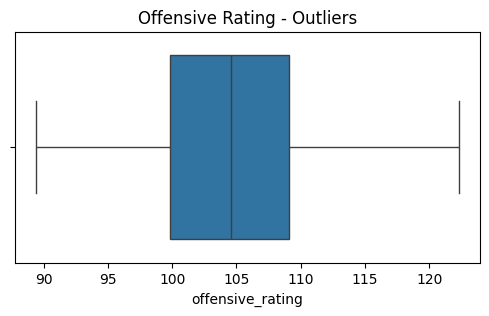

In [20]:
# box plot for offensive rating
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['offensive_rating'])
plt.title('Offensive Rating - Outliers')
plt.show()

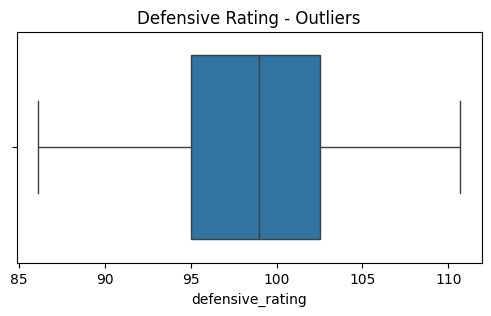

In [21]:
# box plot for defensive rating
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['defensive_rating'])
plt.title('Defensive Rating - Outliers')
plt.show()

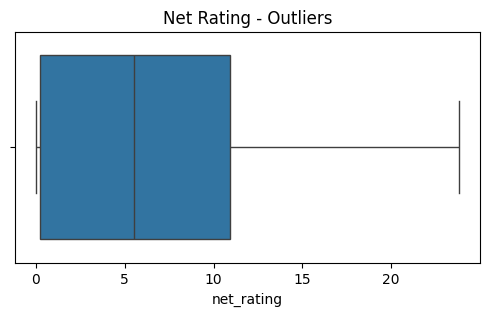

In [22]:
# box plot for net rating
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['net_rating'])
plt.title('Net Rating - Outliers')
plt.show()

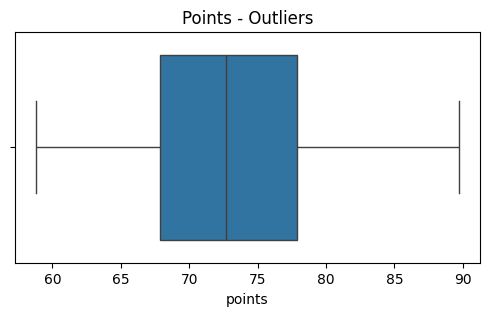

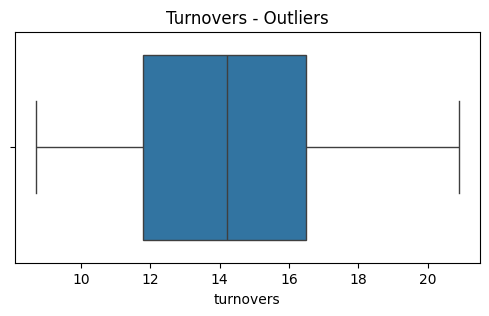

In [23]:
# box plot for points and turnovers
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['points'])
plt.title('Points - Outliers')
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=df['turnovers'])
plt.title('Turnovers - Outliers')
plt.show()

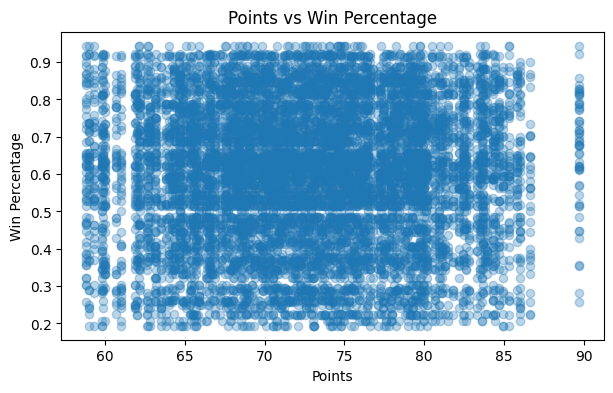

In [24]:
# scatter plot - points vs win percentage
plt.figure(figsize=(7, 4))
plt.scatter(df['points'], df['win_percentage'], alpha=0.3)
plt.xlabel('Points')
plt.ylabel('Win Percentage')
plt.title('Points vs Win Percentage')
plt.show()

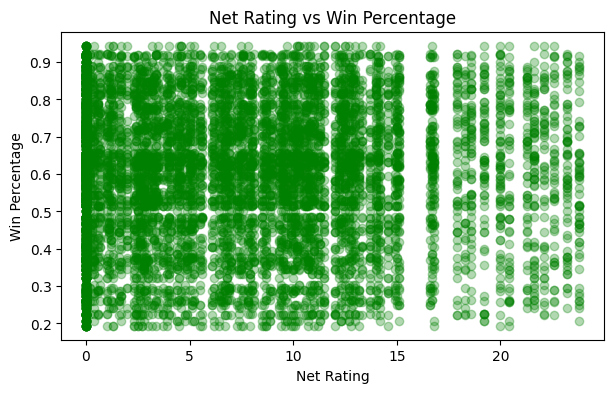

In [25]:
# scatter plot - net rating vs win percentage
plt.figure(figsize=(7, 4))
plt.scatter(df['net_rating'], df['win_percentage'], alpha=0.3, color='green')
plt.xlabel('Net Rating')
plt.ylabel('Win Percentage')
plt.title('Net Rating vs Win Percentage')
plt.show()

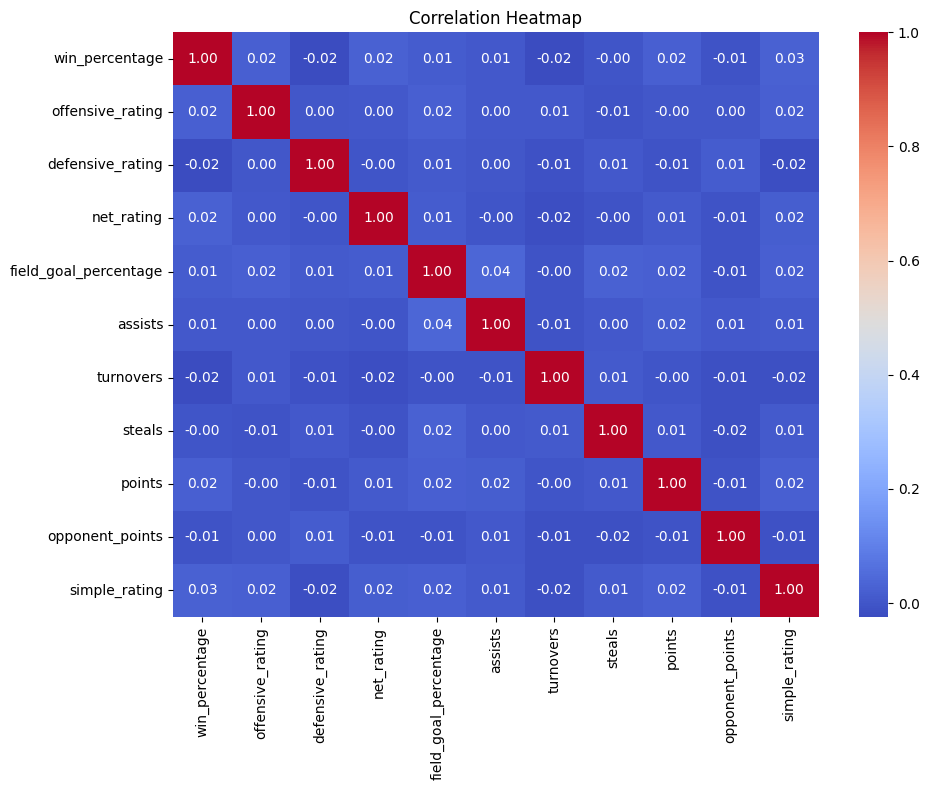

In [26]:
# correlation heatmap to find which features affect win percentage
plt.figure(figsize=(10, 8))
corr = df[['win_percentage', 'offensive_rating', 'defensive_rating', 'net_rating',
            'field_goal_percentage', 'assists', 'turnovers', 'steals',
            'points', 'opponent_points', 'simple_rating']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [27]:
# ---- Feature Engineering ----

# 1. point difference = points scored - opponent points
df['point_diff'] = df['points'] - df['opponent_points']

# 2. assist to turnover ratio
df['assist_turnover_ratio'] = df['assists'] / df['turnovers']

# 3. home win percentage
df['home_win_pct'] = df['home_wins'] / (df['home_wins'] + df['home_losses'])

# 4. away win percentage
df['away_win_pct'] = df['away_wins'] / (df['away_wins'] + df['away_losses'])

# 5. home court advantage = home win% - away win%
df['home_advantage'] = df['home_win_pct'] - df['away_win_pct']

# 6. conference win percentage
df['conf_win_pct'] = df['conference_wins'] / (df['conference_wins'] + df['conference_losses'])

# 7. scoring efficiency = points per shot attempt
df['scoring_efficiency'] = df['points'] / df['field_goal_attempts']

# 8. defensive pressure = steals + blocks
df['defensive_pressure'] = df['steals'] + df['blocks']

print("New features created!")

New features created!


In [28]:
# checking how new features relate to win percentage
new_cols = ['point_diff', 'assist_turnover_ratio', 'home_advantage',
            'conf_win_pct', 'scoring_efficiency', 'defensive_pressure']

for col in new_cols:
    corr_val = df[col].corr(df['win_percentage'])
    print(f"{col} -> correlation with win%: {round(corr_val, 3)}")

point_diff -> correlation with win%: 0.021
assist_turnover_ratio -> correlation with win%: 0.019
home_advantage -> correlation with win%: -0.018
conf_win_pct -> correlation with win%: 0.025
scoring_efficiency -> correlation with win%: 0.019
defensive_pressure -> correlation with win%: 0.008


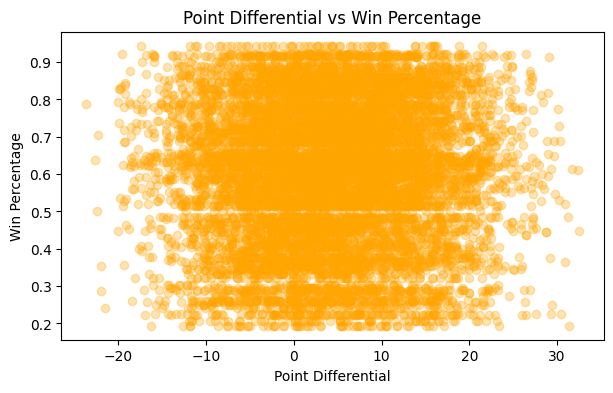

In [29]:
# scatter plot of our best new feature
plt.figure(figsize=(7, 4))
plt.scatter(df['point_diff'], df['win_percentage'], alpha=0.3, color='orange')
plt.xlabel('Point Differential')
plt.ylabel('Win Percentage')
plt.title('Point Differential vs Win Percentage')
plt.show()

In [30]:
# final dataset
print("Final shape:", df.shape)
df.head()

Final shape: (10000, 45)


,id,year,rank,school,games,wins,losses,win_percentage,conference_wins,conference_losses,...,opponent_points,simple_rating,point_diff,assist_turnover_ratio,home_win_pct,away_win_pct,home_advantage,conf_win_pct,scoring_efficiency,defensive_pressure
0,1,2021,1,Villanova,38,30,8,0.789,16,4,...,62.7,19.31,9.0,1.202020,0.923077,0.615385,0.307692,0.800000,1.278075,8.2
1,2,2021,2,Providence,33,27,6,0.818,14,3,...,66.2,13.08,5.3,1.157895,0.941176,0.777778,0.163399,0.823529,1.269982,8.7
2,3,2021,3,UConn,33,23,10,0.697,13,6,...,65.3,16.40,9.5,1.186441,0.875000,0.500000,0.375000,0.684211,1.222222,12.3
3,4,2021,4,Creighton,35,23,12,0.657,12,7,...,66.4,11.34,2.8,0.943262,0.733333,0.545455,0.187879,0.631579,1.209790,9.8
4,5,2021,5,Marquette,32,19,13,0.594,11,8,...,71.6,11.36,2.4,1.290323,0.812500,0.363636,0.448864,0.578947,1.237458,13.0
